# Clasificación de equipos

In [3]:
import os
from ultralytics import YOLO
import cv2
import supervision as sv
import matplotlib.pyplot as plt
import numpy as np
import torch
import cv2
from PIL import Image
from torchvision import transforms
from umap import UMAP
from sklearn.cluster import KMeans
import torch

img_path = os.path.join("..","dataset_engineering", "data_generator","generated_images","20250710_144746_2a1d2c.jpg")

object_detection_model = YOLO(os.path.join("..","object_detection","models","it_2","weights","best.pt"))

def extract_crops(img):
    """
    Dada una imagen extrae recortes de jugadores
    """
    detections = object_detection_model(img,verbose = False)[0]

    clss = detections.boxes.cls

    crops = []
    for i, box in enumerate(detections.boxes.xywh):

        if clss[i] == 1: #es jugador

            x, y, w, h = box
           
            x1 = x - w/2
            x2 = x + w/2
            y1 = y - h/2
            y2 = y + h/2

            crop = img[int(y1):int(y2), int(x1):int(x2)]

            crops.append(crop)

    return crops  


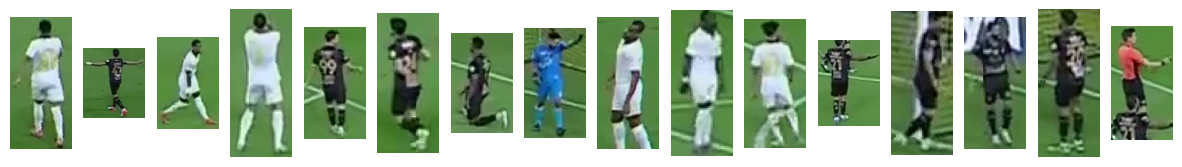

In [4]:
#Ejemplo
crops = extract_crops(cv2.imread(img_path)) 

plt.figure(figsize=(15, 5)) # Tamaño general

for i, crop in enumerate(crops):
    plt.subplot(1, len(crops), i + 1) # (filas, columnas, posición)
    plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)) # Convertir color y mostrar
    plt.axis('off') # Quitar los números

plt.show()


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device)
model.eval()

# transformaciones para las imágenes (DINO requiere 224x224 y normalización)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def get_dino_embeddings(crops):
    embeddings = []
    for crop in crops:
        if crop.size == 0: continue
        
        # Convertir de BGR (OpenCV) a RGB y a PIL Image
        img_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img_rgb)
        
        img_tensor = transform(img_pil).unsqueeze(0).to(device)
        
        with torch.no_grad():
            embedding = model(img_tensor)
            embeddings.append(embedding.cpu().numpy().flatten())
            
    return np.array(embeddings)


features = get_dino_embeddings(crops)

# Reducción de dimensionalidad con UMAP a 3D
reducer = UMAP(n_components=3, random_state=42)
features_3d = reducer.fit_transform(features)

# Clustering  KMeans 2 grupos
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(features_3d)



Using cache found in /home/adrian/.cache/torch/hub/facebookresearch_dinov2_main


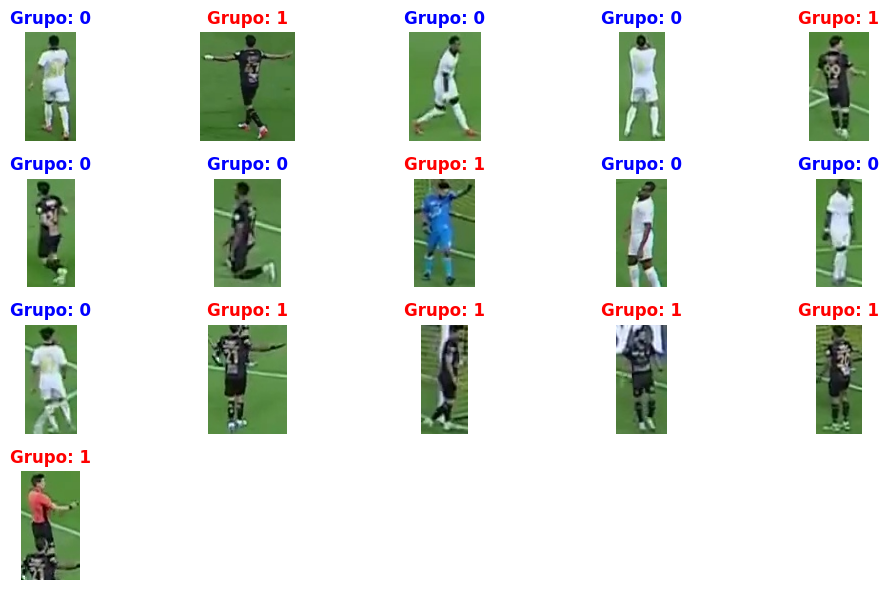

In [6]:
plt.figure(figsize=(10, 6))
cols = 5
rows = (len(crops) // cols) + 1

for i, (crop, label) in enumerate(zip(crops, labels)):
    plt.subplot(rows, cols, i + 1)

    img_show = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    plt.imshow(img_show)
    
    color = 'blue' if label == 0 else 'red'
    plt.title(f"Grupo: {label}", color=color, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()